In [6]:
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
import pandas as pd
import tensorflow as tf
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from keras.models import Sequential,load_model
from keras.layers import LSTM, Dense,Dropout,Bidirectional
from keras.utils import to_categorical
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping


In [7]:
df = pd.read_csv('../dataset/global_dataset.csv')

df.drop(columns=['TaskID','VmID'], inplace=True)  # Features


X = df.drop(['DataCenterID'], axis=1)  # Features
y = df['DataCenterID']-3  # Label

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
unique_labels = np.unique(y_train.values)
print(unique_labels)
print(df.info())
num_classes = len(unique_labels) 


[0 1 2]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   TaskFileSize           2000 non-null   int64  
 1   TaskOutputFileSize     2000 non-null   int64  
 2   TaskFileLength         2000 non-null   int64  
 3   CpuTime                2000 non-null   float64
 4   TotalLength            2000 non-null   int64  
 5   UserLatitude           2000 non-null   float64
 6   UserLongitude          2000 non-null   float64
 7   DataCenterID           2000 non-null   int64  
 8   ENSEMBLE_predicted_DC  2000 non-null   int64  
 9   GA_predicted_DC        2000 non-null   int64  
 10  SNAKE_predicted_DC     2000 non-null   int64  
 11  SNAKE_predicted_VM     2000 non-null   int64  
 12  ENSEMBLE_predicted_VM  2000 non-null   int64  
dtypes: float64(3), int64(10)
memory usage: 203.2 KB
None


In [8]:
# sns.pairplot(df, hue='DataCenterID')
# plt.show()



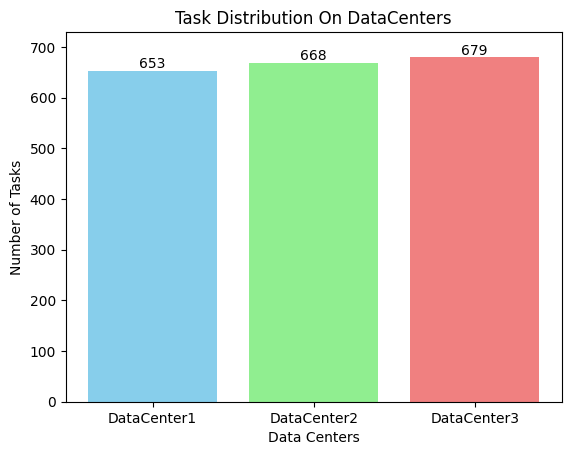

In [9]:

data_center_labels = ['DataCenter1', 'DataCenter2', 'DataCenter3']
tasks_per_data_center = df['DataCenterID'].value_counts().sort_index()

# Assigning colors
colors = ['skyblue', 'lightgreen', 'lightcoral']

# Plotting
fig, ax = plt.subplots()
bars = ax.bar(data_center_labels, tasks_per_data_center, color=colors)

# Displaying the task counts on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

# Adjusting plot properties
plt.title('Task Distribution On DataCenters')
plt.xlabel('Data Centers')
plt.ylabel('Number of Tasks')
plt.ylim(0, max(tasks_per_data_center) + 50)  # Adjust y-axis limit for better visibility
plt.show()


In [10]:
if (len(X_train.shape)<3):
    X_train = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

print(" xtrain ", X_train.shape, "\n", "ytrain ", y_train.shape, "\n", "xtest  ", X_test.shape, "\n", "ytest ", y_test.shape, "\n")




 xtrain  (1600, 1, 12) 
 ytrain  (1600,) 
 xtest   (400, 1, 12) 
 ytest  (400,) 



In [24]:
def trainModel(hyperparameters):
    # Build and train the model
    model = Sequential()
    model.add(LSTM(units=int(hyperparameters['units']), input_shape=(1, X_train.shape[2]), return_sequences=True))
    model.add(Dropout(hyperparameters['dropout_rate']))
    model.add(LSTM(units=int(hyperparameters['units']) // 2))
    model.add(Dense(units=num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=hyperparameters['learning_rate']),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    hist = model.fit(X_train, y_train,
                        epochs=100,
                        batch_size=int(hyperparameters['batch_size']),
                        validation_data=(X_test, y_test),
                       )
    return model,hist
SNAKE_hyperparameters = {'units': 128, 'dropout_rate': 0.01, 'learning_rate': 0.001, 'batch_size': 32}
GA_hyperparameters =   {'units': 70.04564, 'dropout_rate': 0.1, 'learning_rate': 0.0021, 'batch_size': 21}   

ga_model,ga_hist= trainModel(GA_hyperparameters)
ga_accuracy = max(ga_hist.history["accuracy"])

snake_model,snake_hist= trainModel(SNAKE_hyperparameters)
snake_accuracy = max(snake_hist.history["accuracy"])

Epoch 1/100
77/77 [==============================] - 6s 19ms/step - loss: 0.7065 - accuracy: 0.7269 - val_loss: 0.5199 - val_accuracy: 0.7700
Epoch 2/100
77/77 [==============================] - 0s 6ms/step - loss: 0.4913 - accuracy: 0.7931 - val_loss: 0.5012 - val_accuracy: 0.7875
Epoch 3/100
77/77 [==============================] - 0s 6ms/step - loss: 0.4541 - accuracy: 0.8106 - val_loss: 0.5051 - val_accuracy: 0.8025
Epoch 4/100
77/77 [==============================] - 0s 6ms/step - loss: 0.4363 - accuracy: 0.8275 - val_loss: 0.4936 - val_accuracy: 0.7950
Epoch 5/100
77/77 [==============================] - 1s 7ms/step - loss: 0.4258 - accuracy: 0.8225 - val_loss: 0.4241 - val_accuracy: 0.8125
Epoch 6/100
77/77 [==============================] - 1s 8ms/step - loss: 0.4228 - accuracy: 0.8163 - val_loss: 0.4200 - val_accuracy: 0.8175
Epoch 7/100
77/77 [==============================] - 1s 8ms/step - loss: 0.3931 - accuracy: 0.8313 - val_loss: 0.4452 - val_accuracy: 0.8075
Epoch 8/100


In [12]:
print("snake  Accuracy: ",np.round(snake_accuracy* 100) ,'%')
print("GA Accuracy: ",np.round(ga_accuracy* 100) ,'%')

snake  Accuracy:  98.0 %
GA Accuracy:  94.0 %


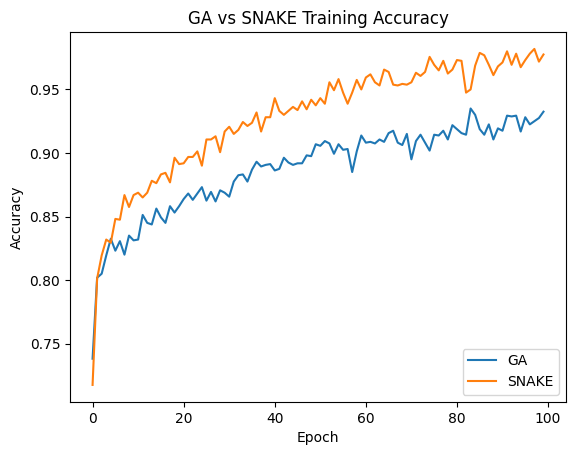

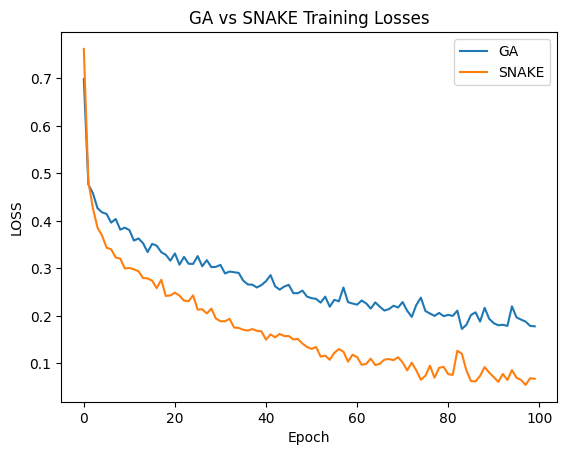



Gentic model summary
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 1, 70)             23240     
                                                                 
 dropout (Dropout)           (None, 1, 70)             0         
                                                                 
 lstm_1 (LSTM)               (None, 35)                14840     
                                                                 
 dense (Dense)               (None, 3)                 108       
                                                                 
Total params: 38188 (149.17 KB)
Trainable params: 38188 (149.17 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


Snake model summary
Model: "sequential_1"
_________________________________________________________________
 Layer (type

In [13]:
plt.plot(ga_hist.history['accuracy'])
plt.plot(snake_hist.history['accuracy'])
plt.title('GA vs SNAKE Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['GA', 'SNAKE'], loc='lower right')
plt.show()

plt.plot(ga_hist.history['loss'])
plt.plot(snake_hist.history['loss'])
plt.title('GA vs SNAKE Training Losses')
plt.xlabel('Epoch')
plt.ylabel('LOSS')
plt.legend(['GA', 'SNAKE'], loc='upper right')
plt.show()

print("\n\nGentic model summary")
print(ga_model.summary())
print("\n\nSnake model summary")
print(snake_model.summary())



13/13 [==============================] - 2s 4ms/step


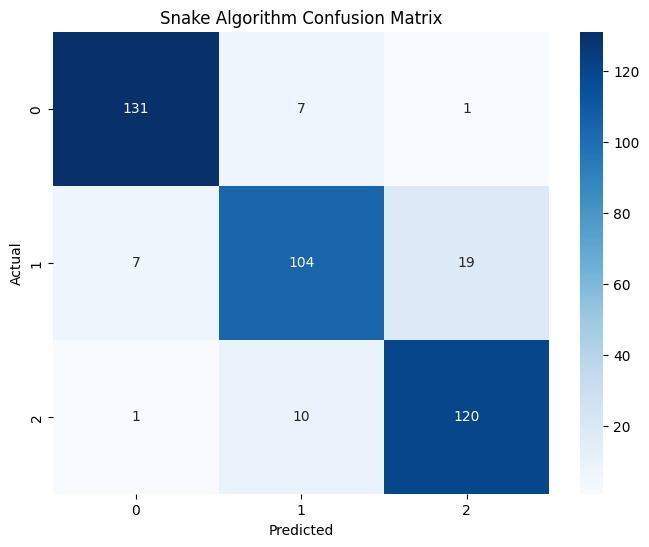

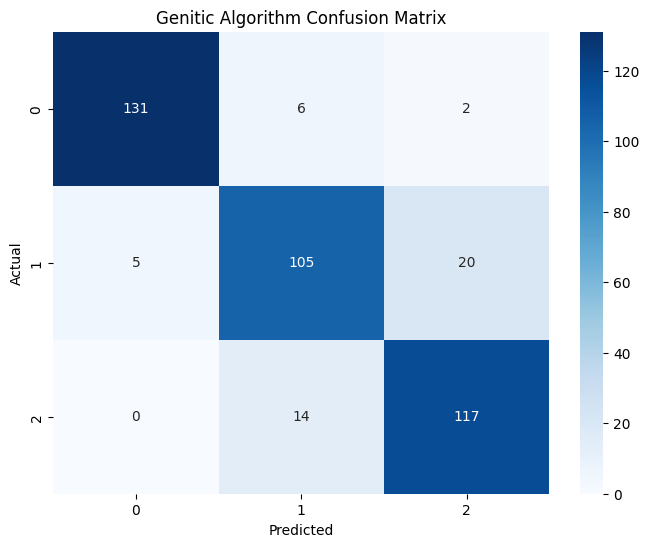

In [14]:
snake_y_pred = snake_model.predict(X_test)
snake_y_pred_classes = np.argmax(snake_y_pred, axis=1)

ga_y_pred = ga_model.predict(X_test)
ga_y_pred_classes = np.argmax(ga_y_pred, axis=1)

# Create a confusion matrix
snake_cm = confusion_matrix(y_test, snake_y_pred_classes)
ga_cm = confusion_matrix(y_test, ga_y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(snake_cm, annot=True, fmt='g', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Snake Algorithm Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


plt.figure(figsize=(8, 6))
sns.heatmap(ga_cm, annot=True, fmt='g', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Genitic Algorithm Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [15]:
# ga_model.save('../models/ga_model_95.keras')
# snake_model.save('../models/snake_model_88.keras')


# SNAKE ALGORITHM

In [17]:

# Define the Search Space
units = [32, 64, 128]
dropout_rates = [0.1, 0.2, 0.3]
learning_rates = [0.001, 0.005]
batch_sizes = [32, 64]

# Initial Random Selection from Search Space
current_hyperparameters = {
    "units": np.random.choice(units),
    "dropout_rate": np.random.choice(dropout_rates),
    "learning_rate": np.random.choice(learning_rates),
    "batch_size": np.random.choice(batch_sizes)
}

# Store the best hyperparameters and accuracy
best_hyperparameters = None
best_accuracy = 0

# Function to train a model with given hyperparameters

# SOA Loop
for iteration in range(10):
    _,hist = trainModel(current_hyperparameters)
    accuracy=hist.history["accuracy"][-1]
    # Update best hyperparameters if better ones are found
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_hyperparameters = current_hyperparameters.copy()

        # Greedy Exploitation: Refine search around the best hyperparameters
        # Here, we're perturbing the hyperparameters slightly
        current_hyperparameters = {
            "units": max(32, best_hyperparameters["units"] + np.random.choice([-16, 16])),
            "dropout_rate": min(0.3, max(0.1, best_hyperparameters["dropout_rate"] + np.random.choice([-0.1, 0.1]))),
            "learning_rate": min(0.005, max(0.001, best_hyperparameters["learning_rate"] * np.random.choice([0.5, 1.5]))),
            "batch_size": max(32, best_hyperparameters["batch_size"] + np.random.choice([-16, 16]))
        }
    else:
        # Random Exploration
        current_hyperparameters = {
            "units": np.random.choice(units),
            "dropout_rate": np.random.choice(dropout_rates),
            "learning_rate": np.random.choice(learning_rates),
            "batch_size": np.random.choice(batch_sizes)
        }

print("Best Hyperparameters:", best_hyperparameters)


Epoch 1/100
25/25 [==============================] - 5s 61ms/step - loss: 0.7654 - accuracy: 0.7262 - val_loss: 0.5531 - val_accuracy: 0.7450
Epoch 2/100
25/25 [==============================] - 0s 7ms/step - loss: 0.5112 - accuracy: 0.7894 - val_loss: 0.5231 - val_accuracy: 0.7850
Epoch 3/100
25/25 [==============================] - 0s 6ms/step - loss: 0.4677 - accuracy: 0.8056 - val_loss: 0.5002 - val_accuracy: 0.7900
Epoch 4/100
25/25 [==============================] - 0s 7ms/step - loss: 0.4490 - accuracy: 0.8037 - val_loss: 0.4408 - val_accuracy: 0.8175
Epoch 5/100
25/25 [==============================] - 0s 7ms/step - loss: 0.4264 - accuracy: 0.8138 - val_loss: 0.4577 - val_accuracy: 0.8000
Epoch 6/100
25/25 [==============================] - 0s 8ms/step - loss: 0.4346 - accuracy: 0.8087 - val_loss: 0.4432 - val_accuracy: 0.8025
Epoch 7/100
25/25 [==============================] - 0s 8ms/step - loss: 0.4167 - accuracy: 0.8188 - val_loss: 0.4437 - val_accuracy: 0.8175
Epoch 8/100


KeyboardInterrupt: 

# GA ALGORITHM

In [19]:
!pip install gaft

Using cached gaft-0.5.7-py3-none-any.whl (39 kB)


In [ ]:
from gaft import GAEngine
from gaft.components import individual, Population,DecimalIndividual
from gaft.operators import RouletteWheelSelection, UniformCrossover, FlipBitMutation

# Define hyperparameter ranges
hyperparameter_ranges = {
    'units': (10,100),
    'dropout_rate': (0.1, 1.0),
    'learning_rate': (0.001, 0.1),
    'batch_size': (10, 100),
  
}

indv_template = DecimalIndividual(ranges=list(hyperparameter_ranges.values()))

# Create population
population = Population(indv_template=indv_template, size=50).init()

# Define Genetic Algorithm operators
selection = RouletteWheelSelection()
crossover = UniformCrossover(pc=0.8, pe=0.5)
mutation = FlipBitMutation(pm=0.1)

# Create Genetic Algorithm engine
engine = GAEngine(population=population, selection=selection, crossover=crossover, mutation=mutation)

@engine.fitness_register
def fitness(indv):
    # Use hyperparameters from individual
    hyperparameters = dict(zip(hyperparameter_ranges.keys(), indv.solution))

    # Train the model with the hyperparameters
    _,hist = trainModel(hyperparameters)  # Call your trainModel function
    accuracy = max(hist.history['accuracy']) # Extract validation accuracy
    print("\nParameters: ",hyperparameters,f" accuracy: {accuracy}")
    print("\n\n\n *********************** New Generation Training Start *******************************\n ")
    return accuracy

# Run the Genetic Algorithm
engine.run(ng=5)

# Access the best individual
best_individual = engine.best_individual()
best_hyperparameters = dict(zip(hyperparameter_ranges.keys(), best_individual.solution))
print("Best hyperparameters: ", best_hyperparameters)


Epoch 1/100
17/17 [==============================] - 5s 71ms/step - loss: 0.8026 - accuracy: 0.6050 - val_loss: 0.6078 - val_accuracy: 0.7200
Epoch 2/100
17/17 [==============================] - 0s 11ms/step - loss: 0.7351 - accuracy: 0.6712 - val_loss: 0.5910 - val_accuracy: 0.7525
Epoch 3/100
17/17 [==============================] - 0s 9ms/step - loss: 0.6927 - accuracy: 0.6981 - val_loss: 0.5633 - val_accuracy: 0.7575
Epoch 4/100
17/17 [==============================] - 0s 10ms/step - loss: 0.6931 - accuracy: 0.7025 - val_loss: 0.5811 - val_accuracy: 0.7375
Epoch 5/100
17/17 [==============================] - 0s 9ms/step - loss: 0.6492 - accuracy: 0.7175 - val_loss: 0.6029 - val_accuracy: 0.7275
Epoch 6/100
17/17 [==============================] - 0s 9ms/step - loss: 0.7154 - accuracy: 0.6725 - val_loss: 0.6990 - val_accuracy: 0.6800
Epoch 7/100
17/17 [==============================] - 0s 10ms/step - loss: 0.7078 - accuracy: 0.6706 - val_loss: 0.6211 - val_accuracy: 0.7100
Epoch 8/1